# Прогнозирование числового отклика. Сравнение линейных и нелинейных подходов
**Цель работы:**  
Построить регрессионные модели (только по людям, кто пожертвовал деньги), объясняющие и прогнозирующие сумму пожертвования.

**Задачи**
1. Выделить holdout (30%) со стратификацией по дискретизированному отклику и визуализировать распределение отклика.

2. Заполнить пропуски, добавив бинарные признаки о факте заполнения.

3. Провести отбор признаков линейным методом, перебрать все сложности, выбрать лучшую по CV-MSE, построить графики зависимости ошибки и трасс коэффициентов.

4. Для лучшей линейной модели выполнить бутстреппинг (100 выборок по 25% данных), оценить распределение константы и OOB MSE, сравнить с CV и holdout ошибками.

5. Построить нелинейную модель (MLP) на отобранных признаках, подобрать гиперпараметры.

6. Построить график-решётку перебора гиперпараметров и сравнить качество линейной и нелинейной моделей.

## Информация о датасете

### 1. Идентификаторы и целевые переменные

| Признак | Тип | Описание |
|---------|------|-----------|
| `ID` | Character | Уникальный идентификатор человека (контрольный номер) |
| `TargetB` | Numeric (флаг) | Бинарный отклик: пожертвовал (1) или нет (0) |
| `TargetD` | Currency | Целевая переменная (регрессия): сумма пожертвования в долларах. Пропуск (NaN), если человек не жертвовал |

### 2. Поведенческие признаки (история пожертвований)

| Признак | Описание |
|---------|-----------|
| `GiftCnt36` | Число пожертвований за последние 36 месяцев |
| `GiftCntAll` | Общее число пожертвований за всё время |
| `GiftCntCard36` | Число пожертвований по карте за 36 месяцев |
| `GiftCntCardAll` | Общее число пожертвований по карте |
| `GiftAvgLast` | Сумма последнего пожертвования |
| `GiftAvg36` | Средняя сумма пожертвования за 36 месяцев |
| `GiftAvgAll` | Средняя сумма пожертвования за всё время |
| `GiftAvgCard36` | Средняя сумма пожертвования по карте за 36 месяцев |
| `GiftTimeLast` | Время (в днях/месяцах) с момента последнего пожертвования |
| `GiftTimeFirst` | Время с момента первого пожертвования |

### 3. Маркетинговые признаки (контакты с организацией)

| Признак | Описание |
|---------|-----------|
| `PromCnt12` | Число рекламных контактов с ним за 12 месяцев |
| `PromCnt36` | Число рекламных контактов за 36 месяцев |
| `PromCntAll` | Общее число рекламных контактов |
| `PromCntCard12` | Число контактов по карте за 12 месяцев |
| `PromCntCard36` | Число контактов по карте за 36 месяцев |
| `PromCntCardAll` | Общее число контактов по карте |

### 4. Социо-демографические признаки

| Признак | Тип | Описание |
|---------|------|-----------|
| `StatusCat96NK` | Character | Категория статуса (например, "домашний владелец/арендатор" и т.д.) |
| `StatusCatStarAll` | Numeric | Числовая категория статуса |
| `DemCluster` | Character | Демографический кластер (группа по поведению/доходу) |
| `DemAge` | Numeric | Возраст |
| `DemGender` | Character | Пол (M/F и т.д.) |
| `DemHomeOwner` | Character | Является ли домовладельцем (Y/N) |
| `DemMedHomeValue` | Currency | Медианная стоимость дома в районе проживания |
| `DemPctVeterans` | Numeric | Процент ветеранов в районе проживания |
| `DemMedIncome` | Currency | Медианный доход в районе проживания |

In [42]:
#импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore')
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.utils import resample
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import BaggingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

In [43]:
df = pd.read_csv('donations.csv')
df.head()

,TargetB,ID,TargetD,GiftCnt36,GiftCntAll,GiftCntCard36,GiftCntCardAll,GiftAvgLast,GiftAvg36,GiftAvgAll,...,PromCntCardAll,StatusCat96NK,StatusCatStarAll,DemCluster,DemAge,DemGender,DemHomeOwner,DemMedHomeValue,DemPctVeterans,DemMedIncome
0,0,14974,NaN,2,4,1,3,17.0,13.50,9.25,...,13,A,0,0,NaN,F,U,0,0,NaN
1,0,6294,NaN,1,8,0,3,20.0,20.00,15.88,...,24,A,0,23,67.0,F,U,186800,85,NaN
2,1,46110,4.0,6,41,3,20,6.0,5.17,3.73,...,22,S,1,0,NaN,M,U,87600,36,38750.0
3,1,185937,10.0,3,12,3,8,10.0,8.67,8.50,...,16,E,1,0,NaN,M,U,139200,27,38942.0
4,0,29637,NaN,1,1,1,1,20.0,20.00,20.00,...,6,F,0,35,53.0,M,U,168100,37,71509.0


## 1. Проверочная выборка (holdout) со стратификацией по отклику


In [44]:
df_donors = df[df['TargetB'] == 1].copy()
n_bins = 4  # число интервалов для стратификации
df_donors['TargetD_strat'] = pd.qcut(df_donors['TargetD'], q=n_bins, labels=False)
X = df_donors.drop(columns=['TargetD', 'TargetD_strat', 'TargetB', 'ID'], errors='ignore')
y = df_donors['TargetD']  # целевая переменная (непрерывная)
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y,
    test_size=0.3,                      # 30% в holdout
    stratify=df_donors['TargetD_strat'], # стратификация
    random_state=42
)
print("Проверка стратификации (доли каждой группы):")
print("Train:", df_donors.loc[X_train.index, 'TargetD_strat'].value_counts(normalize=True).sort_index().round(3).tolist())
print("Holdout:", df_donors.loc[X_holdout.index, 'TargetD_strat'].value_counts(normalize=True).sort_index().round(3).tolist())


Проверка стратификации (доли каждой группы):
Train: [0.428, 0.073, 0.302, 0.196]
Holdout: [0.428, 0.073, 0.303, 0.196]


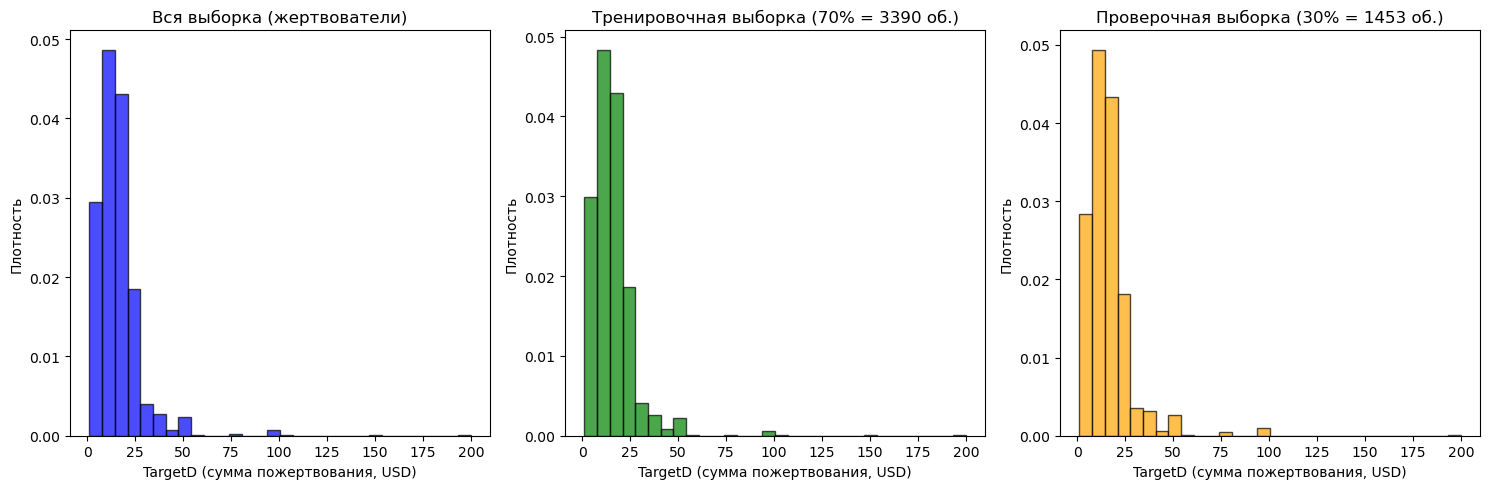

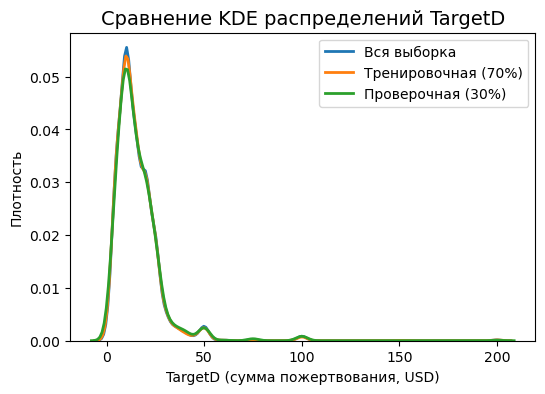

In [45]:
#визуализация
train_targets = y_train
holdout_targets = y_holdout
all_targets = df_donors['TargetD']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(all_targets, bins=30, density=True, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Вся выборка (жертвователи)', fontsize=12)
axes[0].set_xlabel('TargetD (сумма пожертвования, USD)')
axes[0].set_ylabel('Плотность')

axes[1].hist(train_targets, bins=30, density=True, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title(f'Тренировочная выборка (70% = {len(train_targets)} об.)', fontsize=12)
axes[1].set_xlabel('TargetD (сумма пожертвования, USD)')
axes[1].set_ylabel('Плотность')

axes[2].hist(holdout_targets, bins=30, density=True, alpha=0.7, color='orange', edgecolor='black')
axes[2].set_title(f'Проверочная выборка (30% = {len(holdout_targets)} об.)', fontsize=12)
axes[2].set_xlabel('TargetD (сумма пожертвования, USD)')
axes[2].set_ylabel('Плотность')

plt.tight_layout()
plt.show()
plt.figure(figsize=(6, 4))
sns.kdeplot(all_targets, label='Вся выборка', linewidth=2)
sns.kdeplot(train_targets, label='Тренировочная (70%)', linewidth=2)
sns.kdeplot(holdout_targets, label='Проверочная (30%)', linewidth=2)
plt.title('Сравнение KDE распределений TargetD', fontsize=14)
plt.xlabel('TargetD (сумма пожертвования, USD)')
plt.ylabel('Плотность')
plt.legend()
plt.show()

Стратификация выполнена успешно. Распределение сохранено в каждой выборке.

## 2. Заполнение пропусков

In [46]:
#признаки с пропусками
missing_before = X_train.isnull().sum()
missing_before = missing_before[missing_before > 0]
missing_before

GiftAvgCard36    518
DemAge           840
DemMedIncome     843
dtype: int64

In [47]:
#изучим категориальные признаки
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols

['StatusCat96NK', 'DemGender', 'DemHomeOwner']

In [48]:
#создадим индикаторы для заполнения пропусков
X_train_processed = X_train.copy()
X_holdout_processed = X_holdout.copy()
cols_with_missing = missing_before.index.tolist()
indicators_created = []
for col in cols_with_missing:
    if col in numeric_cols:
        indicator_name = f"{col}_was_missing"
        #cоздаём индикатор: 1 если было пропущено, 0 если нет
        X_train_processed[indicator_name] = X_train_processed[col].isnull().astype(int)
        X_holdout_processed[indicator_name] = X_holdout_processed[col].isnull().astype(int)
        indicators_created.append(indicator_name)
indicators_created
        

['GiftAvgCard36_was_missing', 'DemAge_was_missing', 'DemMedIncome_was_missing']

In [49]:
#выполним подстановку пропусков средним значением с помощью SimpleImputer
#cоздаём и обучаем imputer на тренировочной выборке
imputer = SimpleImputer(strategy='mean')
imputer.fit(X_train_processed[numeric_cols])
#применяем imputer к тренировочной и holdout выборкам
X_train_processed[numeric_cols] = imputer.transform(X_train_processed[numeric_cols])
X_holdout_processed[numeric_cols] = imputer.transform(X_holdout_processed[numeric_cols])
X_train_processed[numeric_cols].isnull().sum()

GiftCnt36           0
GiftCntAll          0
GiftCntCard36       0
GiftCntCardAll      0
GiftAvgLast         0
GiftAvg36           0
GiftAvgAll          0
GiftAvgCard36       0
GiftTimeLast        0
GiftTimeFirst       0
PromCnt12           0
PromCnt36           0
PromCntAll          0
PromCntCard12       0
PromCntCard36       0
PromCntCardAll      0
StatusCatStarAll    0
DemCluster          0
DemAge              0
DemMedHomeValue     0
DemPctVeterans      0
DemMedIncome        0
dtype: int64

In [50]:
X_holdout_processed[numeric_cols].isnull().sum()

GiftCnt36           0
GiftCntAll          0
GiftCntCard36       0
GiftCntCardAll      0
GiftAvgLast         0
GiftAvg36           0
GiftAvgAll          0
GiftAvgCard36       0
GiftTimeLast        0
GiftTimeFirst       0
PromCnt12           0
PromCnt36           0
PromCntAll          0
PromCntCard12       0
PromCntCard36       0
PromCntCardAll      0
StatusCatStarAll    0
DemCluster          0
DemAge              0
DemMedHomeValue     0
DemPctVeterans      0
DemMedIncome        0
dtype: int64

Пропуски заполнены успешно. SimpleImputer обучался на тренировочной выборке, чтобы не было утечки данных из train в holdout. 

## 3. Отбор важных переменных с помощью ForwardOLS

In [51]:
#числовые колонки + стандартизация
numeric_cols = X_train_processed.select_dtypes(include=[np.number]).columns.tolist()
X_train_num = X_train_processed[numeric_cols]
X_holdout_num = X_holdout_processed[numeric_cols]

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num),
    columns=X_train_num.columns,
    index=X_train_num.index
)
X_holdout_scaled = pd.DataFrame(
    scaler.transform(X_holdout_num),
    columns=X_holdout_num.columns,
    index=X_holdout_num.index
)
X_train_scaled.head()

,GiftCnt36,GiftCntAll,GiftCntCard36,GiftCntCardAll,GiftAvgLast,GiftAvg36,GiftAvgAll,GiftAvgCard36,GiftTimeLast,GiftTimeFirst,...,PromCntCardAll,StatusCatStarAll,DemCluster,DemAge,DemMedHomeValue,DemPctVeterans,DemMedIncome,GiftAvgCard36_was_missing,DemAge_was_missing,DemMedIncome_was_missing
6959,-1.129199,1.526648,-1.233598,0.785759,-0.299671,-0.320283,-0.442624,0.000000,0.095081,1.444340,...,0.977995,0.831128,-1.803940,-3.807311,-0.162196,-2.634188,-1.047376,2.354655,-0.573944,-0.575307
1459,0.693868,-0.163741,0.574399,0.176304,0.367710,0.090242,-0.054696,-0.042318,-0.371717,-0.481026,...,0.038122,0.831128,-0.249469,0.657724,-0.192176,0.620522,0.485851,-0.424691,-0.573944,-0.575307
6641,-0.673432,-0.903286,-0.630932,-0.839454,-0.373825,0.381931,0.610192,1.302197,0.328479,-0.801920,...,-0.666783,-1.203185,-1.060497,-2.078910,-0.064517,-0.150330,0.861485,-0.424691,-0.573944,-0.575307
6016,0.238101,-0.797637,1.177065,-0.433151,-0.373825,-0.698398,-0.399728,-0.658554,-0.371717,-1.203038,...,-1.136720,0.831128,-1.060497,1.809991,1.255589,0.020970,-0.986752,-0.424691,-0.573944,-0.575307
2302,-0.673432,-0.375039,-0.630932,-0.839454,0.738477,1.192177,0.369602,1.302197,1.262074,0.080539,...,0.390574,-1.203185,0.831902,0.153607,-0.687337,1.562675,-0.177028,-0.424691,-0.573944,-0.575307


In [52]:
cv_errors = []      # CV-MSE для каждой сложности
complexities = []   # число признаков
coefs_history = []  # история коэффициентов для графика трасс
features_history = []  # история отобранных признаков

estimator = LinearRegression()
for k in range(1, X_train_scaled.shape[1]):
    # Forward OLS для отбора k признаков
    sfs = SequentialFeatureSelector(
        estimator=estimator,
        n_features_to_select=k,
        direction='forward',
        scoring='neg_mean_squared_error',
        cv=5,
        n_jobs=-1
    )
    sfs.fit(X_train_scaled, y_train)
    
    #отобранные признаки
    mask = sfs.get_support()
    selected_cols = X_train_scaled.columns[mask].tolist()
    features_history.append(selected_cols)
    
    #считаем CV-MSE для модели с этими признаками
    model = LinearRegression()
    cv_scores = cross_val_score(model, X_train_scaled[selected_cols], y_train,
                                 cv=5, scoring='neg_mean_squared_error')
    cv_mse = -np.mean(cv_scores)
    cv_errors.append(cv_mse)
    complexities.append(k)
    
    #обучаем финальную модель для получения коэффициентов
    model.fit(X_train_scaled[selected_cols], y_train)
    
    #сохраняем коэффициенты (для всех признаков, ноль если не отобран)
    coef_row = np.zeros(X_train_scaled.shape[1])
    for i, col in enumerate(X_train_scaled.columns):
        if col in selected_cols:
            idx = selected_cols.index(col)
            coef_row[i] = model.coef_[idx]
    coefs_history.append(coef_row)

Лучшая сложность: 10 признаков
Минимальная CV-MSE: 78.674976
Отобранные признаки: ['GiftCnt36', 'GiftCntCard36', 'GiftAvg36', 'GiftAvgCard36', 'GiftTimeLast', 'GiftTimeFirst', 'PromCntCard12', 'StatusCatStarAll', 'DemCluster', 'GiftAvgCard36_was_missing']


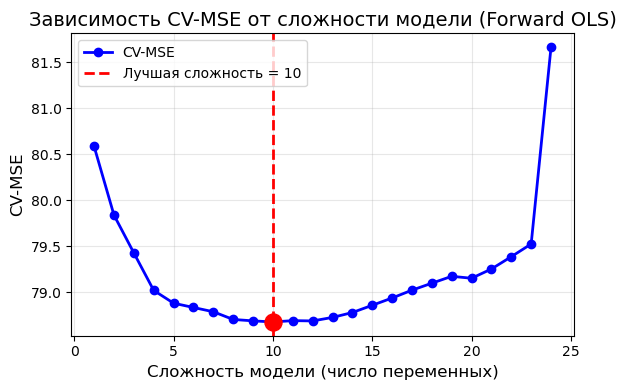

In [53]:
#выбор лучшей сложности
best_idx = np.argmin(cv_errors)
best_complexity = complexities[best_idx]
best_cv_mse = cv_errors[best_idx]
best_features = features_history[best_idx]
print(f"Лучшая сложность: {best_complexity} признаков")
print(f"Минимальная CV-MSE: {best_cv_mse:.6f}")
print(f"Отобранные признаки: {best_features}")
plt.figure(figsize=(6, 4))
plt.plot(complexities, cv_errors, 'bo-', linewidth=2, markersize=6, label='CV-MSE')
plt.axvline(x=best_complexity, color='red', linestyle='--', linewidth=2,
            label=f'Лучшая сложность = {best_complexity}')
plt.scatter(best_complexity, best_cv_mse, color='red', s=150, zorder=5)
plt.xlabel('Сложность модели (число переменных)', fontsize=12)
plt.ylabel('CV-MSE', fontsize=12)
plt.title('Зависимость CV-MSE от сложности модели (Forward OLS)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

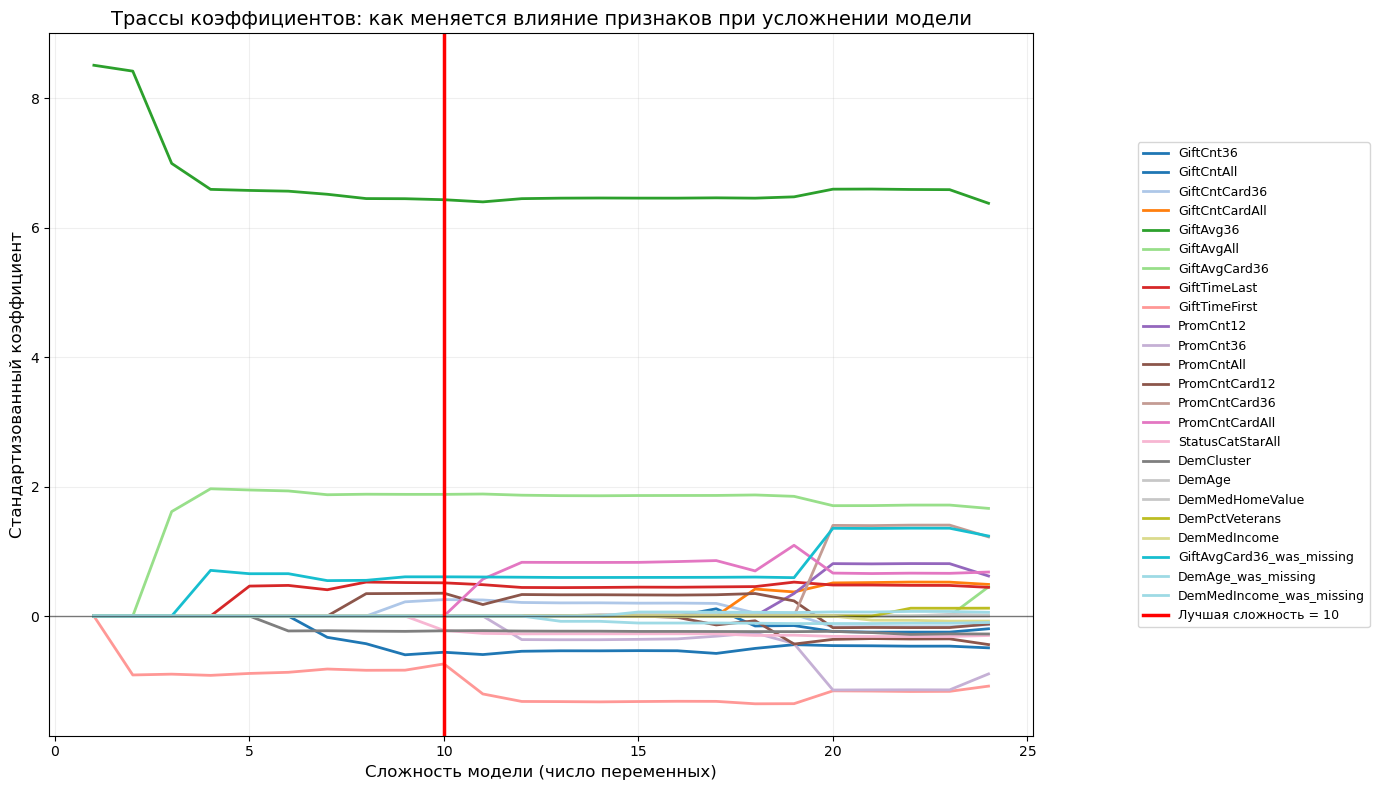

In [54]:
num_features = X_train_scaled.shape[1]
import matplotlib.cm as cm 
colors = cm.get_cmap('tab20', num_features).colors # Палитра из 20+ четких цветов

plt.figure(figsize=(14, 8))
coefs_array = np.array(coefs_history).T 
line_styles = ['-', '--', '-.', ':']

for i, col in enumerate(X_train_scaled.columns):
    if np.max(np.abs(coefs_array[i])) > 1e-6:
        color = colors[i % len(colors)]
        style = line_styles[(i // len(colors)) % len(line_styles)]
        
        line, = plt.plot(complexities, coefs_array[i], 
                         linewidth=2, 
                         color=color, 
                         linestyle=style, 
                         label=col)
plt.axvline(x=best_complexity, color='red', linestyle='-', linewidth=2.5,
            label=f'Лучшая сложность = {best_complexity}')
plt.axhline(y=0, color='black', linewidth=1, alpha=0.5)

plt.xlabel('Сложность модели (число переменных)', fontsize=12)
plt.ylabel('Стандартизованный коэффициент', fontsize=12)
plt.title('Трассы коэффициентов: как меняется влияние признаков при усложнении модели', fontsize=14)
plt.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), fontsize=9, ncol=1)

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


 Отрицательно коррелируемые признаки:
 
 GiftTimeFirst - Чем «старее» донор, тем меньше он склонен жертвовать крупные суммы сейчас.

 GiftCntAll - чем чаще человек жертвовал в прошлом, тем меньше сумма пожертвования.

 DemCluster - Принадлежность к определенным группам снижает ожидаемый чек.

 StatusCatStarAll (Числовая категория статуса) - Чем выше числовой статус, тем ниже сумма

Holdout MSE: 69.524569
Дисперсия y_train: 152.61
Дисперсия y_holdout: 160.22
y_holdout среднее: 15.84
y_train среднее: 15.53
R2 Train: 0.4896
R2 Holdout: 0.5658


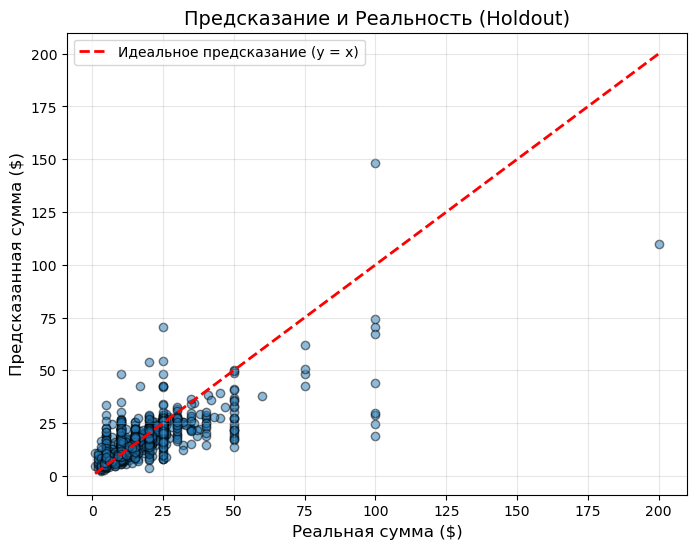

In [55]:
#итоговая модель
from sklearn.metrics import mean_squared_error
holdout_model = LinearRegression()
holdout_model.fit(X_train_scaled[best_features], y_train)
y_pred_holdout = holdout_model.predict(X_holdout_scaled[best_features])
holdout_mse = mean_squared_error(y_holdout, y_pred_holdout)
print(f"Holdout MSE: {holdout_mse:.6f}")
print(f"Дисперсия y_train: {y_train.var():.2f}")
print(f"Дисперсия y_holdout: {y_holdout.var():.2f}")
print(f"y_holdout среднее: {y_holdout.mean():.2f}")
print(f"y_train среднее: {y_train.mean():.2f}")
from sklearn.metrics import r2_score
print(f"R2 Train: {holdout_model.score(X_train_scaled[best_features], y_train):.4f}")
print(f"R2 Holdout: {r2_score(y_holdout, y_pred_holdout):.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_holdout, y_pred_holdout, alpha=0.5, edgecolors='k')
plt.plot([y_holdout.min(), y_holdout.max()], 
         [y_holdout.min(), y_holdout.max()], 
         'r--', lw=2, label='Идеальное предсказание (y = x)')
plt.xlabel('Реальная сумма ($)', fontsize=12)
plt.ylabel('Предсказанная сумма ($)', fontsize=12)
plt.title('Предсказание и Реальность (Holdout)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Модель демонстрирует отсутствие переобучения (R² на holdout выше, чем на train — 0.57 против 0.49), но ошибка остаётся значительной: MSE = 8.34 доллара при среднем пожертвовании 15.84 доллара.

## 4. Формирование бутстреп выборок и оценка константы смещения и OOB ошибки

In [56]:
X_best = X_train_scaled[best_features].copy()
y_best = y_train.copy()
print(f"Данные для бутстреппинга:")
print(f"  Объектов: {len(X_best)}")
print(f"  Признаков: {len(best_features)}")
n_bootstrap = 100                      # количество бутстреп выборок
sample_size = int(0.25 * len(X_best))  # 25% от исходной выборки
print(f"  Количество бутстреп выборок: {n_bootstrap}")
print(f"  Размер каждой выборки: {sample_size} (25% от {len(X_best)})")

Данные для бутстреппинга:
  Объектов: 3390
  Признаков: 10
  Количество бутстреп выборок: 100
  Размер каждой выборки: 847 (25% от 3390)


OOB ошибка MSE ансамбля: 79.5636


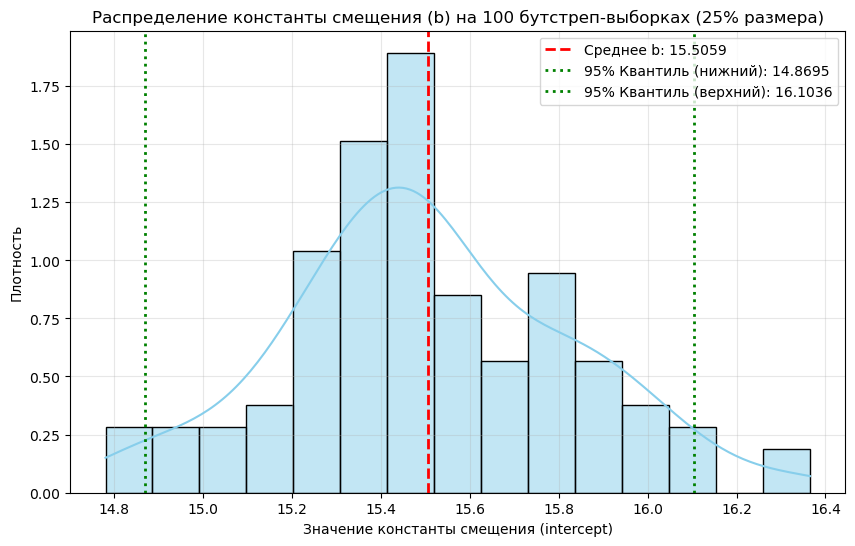

Константа b: Среднее = 15.5059, 95% интервал = [14.8695, 16.1036]


In [57]:
bagging_oob = BaggingRegressor(
    estimator=LinearRegression(),
    n_estimators=100, 
    max_samples=0.25,     
    bootstrap=True,
    oob_score=True, 
    random_state=42
)
bagging_oob.fit(X_best, y_best)
#константы b из базовых моделей
intercepts = np.array([est.intercept_ for est in bagging_oob.estimators_])
#OOB предсказания
oob_predictions = bagging_oob.oob_prediction_
# фильтруем NaN
nan_mask = np.isnan(oob_predictions)
if np.any(nan_mask):
    y_best_filtered = y_best[~nan_mask]
    oob_predictions_filtered = oob_predictions[~nan_mask]
else:
    y_best_filtered = y_best
    oob_predictions_filtered = oob_predictions
#OOB MSE
oob_mse = mean_squared_error(y_best_filtered, oob_predictions_filtered)
print(f"OOB ошибка MSE ансамбля: {oob_mse:.4f}")
# статистика константы b
mean_b = np.mean(intercepts)
ci_lower = np.percentile(intercepts, 2.5)
ci_upper = np.percentile(intercepts, 97.5)
plt.figure(figsize=(10, 6))
sns.histplot(intercepts, kde=True, color='skyblue', bins=15, stat="density")

plt.axvline(mean_b, color='red', linestyle='--', linewidth=2, label=f'Среднее b: {mean_b:.4f}')
plt.axvline(ci_lower, color='green', linestyle=':', linewidth=2, label=f'95% Квантиль (нижний): {ci_lower:.4f}')
plt.axvline(ci_upper, color='green', linestyle=':', linewidth=2, label=f'95% Квантиль (верхний): {ci_upper:.4f}')

plt.title('Распределение константы смещения (b) на 100 бутстреп-выборках (25% размера)')
plt.xlabel('Значение константы смещения (intercept)')
plt.ylabel('Плотность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Константа b: Среднее = {mean_b:.4f}, 95% интервал = [{ci_lower:.4f}, {ci_upper:.4f}]")


OOB-ошибка (79.56) оказалась самой высокой среди всех финальных оценок, но близка к оценке CV, следовательно, модель обладает стаблильностью.
Бутстреппинг показал, что константа смещения b устойчива: её среднее значение составляет 15.51 доллара, а ширина интервала всего 1.23 доллара, что свидетельствует о стабильности модели при изменении обучающей выборки.

## 5. Построение нелинейной модели с помощью MLP (функция активации relu) и HalvingRandomSearchCV 


In [58]:
from sklearn.neural_network import MLPRegressor
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
X_train_mlp = X_train_scaled[best_features].copy()
X_holdout_mlp = X_holdout_scaled[best_features].copy()
print(f"Данные для MLP:")
print(f"   Обучающая выборка: {X_train_mlp.shape}")
print(f"   Проверочная выборка: {X_holdout_mlp.shape}")
print(f"   Отобранные признаки ({len(best_features)} шт.): {best_features}")

Данные для MLP:
   Обучающая выборка: (3390, 10)
   Проверочная выборка: (1453, 10)
   Отобранные признаки (10 шт.): ['GiftCnt36', 'GiftCntCard36', 'GiftAvg36', 'GiftAvgCard36', 'GiftTimeLast', 'GiftTimeFirst', 'PromCntCard12', 'StatusCatStarAll', 'DemCluster', 'GiftAvgCard36_was_missing']


In [59]:
param_distributions = {
    'hidden_layer_sizes': [(10,), (20,), (50,), (100,), (150,), (20,10), (10,5), (50,10)], 
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0], 
    'learning_rate_init': [0.001, 0.01]
}

mlp = MLPRegressor(
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

halving_search = HalvingRandomSearchCV(
    estimator=mlp,
    param_distributions=param_distributions,
    n_candidates='exhaust', # Проверить максимум возможных комбинаций
    factor=3, #выбрасывается 1/3 худших возможных комбинаций
    resource='n_samples', #увеличиваем количество строк
    min_resources=500, #сколько строк данных получит модель на самом первом этапе
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1 
)

halving_search.fit(X_train_mlp, y_train)

# Вывод результатов
print(f"Лучшие параметры: {halving_search.best_params_}")
print(f"Лучшая CV-MSE: {-halving_search.best_score_:.6f}")

Лучшие параметры: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (50, 10), 'alpha': 0.001}
Лучшая CV-MSE: 86.158752


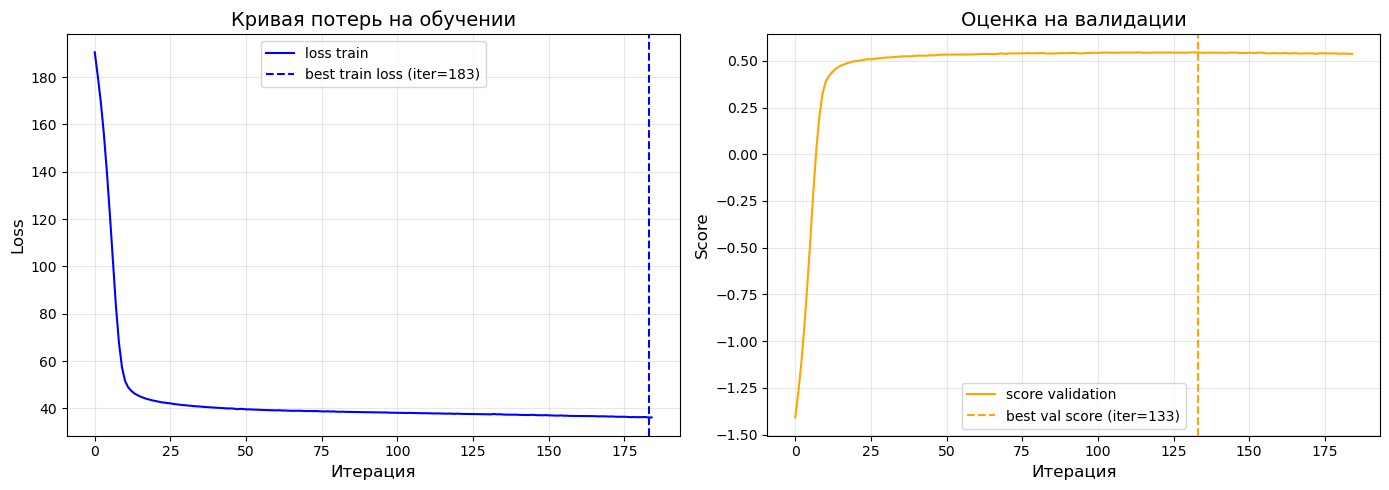

Финальный MSE нейросети: 68.340258


In [60]:
best_mlp = halving_search.best_estimator_
final_mlp = MLPRegressor(
    hidden_layer_sizes=halving_search.best_params_.get('hidden_layer_sizes', (100,)),
    activation='relu',
    solver='adam',
    alpha=halving_search.best_params_.get('alpha', 0.001),
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=halving_search.best_params_.get('learning_rate_init', 0.001),
    tol=1e-4,
    max_iter=3000,
    validation_fraction=0.1,
    early_stopping=True,
    n_iter_no_change=50,
    random_state=42
)
final_mlp.fit(X_train_mlp, y_train)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(final_mlp.n_iter_), final_mlp.loss_curve_, label='loss train', color='blue')
best_tr_iter = np.argmin(final_mlp.loss_curve_)
axes[0].axvline(best_tr_iter, color='blue', linestyle='--', label=f'best train loss (iter={best_tr_iter})')
axes[0].set_xlabel('Итерация', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Кривая потерь на обучении', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
if hasattr(final_mlp, 'validation_scores_') and final_mlp.validation_scores_:
    axes[1].plot(range(len(final_mlp.validation_scores_)), final_mlp.validation_scores_, 
                 label='score validation', color='orange')
    best_val_iter = np.argmax(final_mlp.validation_scores_)
    axes[1].axvline(best_val_iter, color='orange', linestyle='--', 
                    label=f'best val score (iter={best_val_iter})')
    axes[1].set_xlabel('Итерация', fontsize=12)
    axes[1].set_ylabel('Score', fontsize=12)
    axes[1].set_title('Оценка на валидации', fontsize=14)
else:
    axes[1].text(0.5, 0.5, 'validation_scores_ не доступны\n(early_stopping=True)', 
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Оценка на валидации', fontsize=14)

axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
y_pred_final = final_mlp.predict(X_holdout_mlp)
print(f"Финальный MSE нейросети: {mean_squared_error(y_holdout, y_pred_final):.6f}")



## 6. Решетка перебора метапараметров

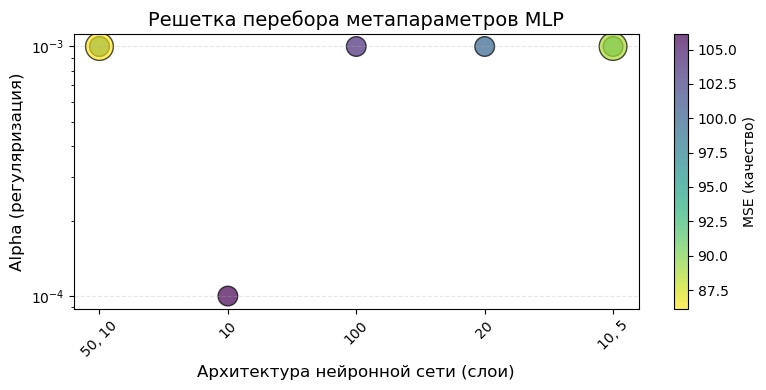

In [61]:
results = pd.DataFrame(halving_search.cv_results_)
results['arch_name'] = results['param_hidden_layer_sizes'].apply(lambda x: ', '.join(map(str, x)))
results['mse'] = -results['mean_test_score'] 

plt.figure(figsize=(8, 4))
sizes = (results['iter'] + 1) * 200 
scatter = plt.scatter(
    results['arch_name'], 
    results['param_alpha'], 
    c=results['mse'], 
    s=sizes, 
    cmap='viridis_r', 
    alpha=0.7, 
    edgecolors='black'
)

plt.yscale('log')
plt.colorbar(scatter, label='MSE (качество)')
plt.xlabel('Архитектура нейронной сети (слои)', fontsize=12)
plt.ylabel('Alpha (регуляризация)', fontsize=12)
plt.title('Решетка перебора метапараметров MLP', fontsize=14)
plt.xticks(rotation=45) 
plt.grid(True, axis='y', ls="--", alpha=0.3)

plt.tight_layout()
plt.show()


## Выводы

В ходе работы были решены задачи прогнозирования суммы пожертвования с использованием линейных и нелинейных методов машинного обучения.

Выполнено формирование holdout-выборки (30%) со стратификацией по дискретизированному отклику, что позволило сохранить распределение целевой переменной. Пропуски в признаках `GiftAvgCard36`, `DemAge` и `DemMedIncome` заполнены средними значениями с добавлением бинарных индикаторов факта пропуска, что предотвратило утечку данных из тренировочной выборки.

С помощью последовательного отбора признаков (Forward OLS) определена оптимальная сложность модели — 10 переменных. Анализ трасс коэффициентов показал, что наиболее сильное отрицательное влияние на сумму пожертвования оказывают признаки `GiftTimeFirst` и `DemCluster`, а положительное — `GiftTimeLast`. Линейная модель показала хорошую обобщающую способность: R² на holdout (0,566) оказался выше, чем на обучении (0,489), что свидетельствует об отсутствии переобучения. MSE на holdout составила 69,52.

Для оценки стабильности модели выполнен бутстреппинг (100 выборок по 25% данных). Среднее значение константы смещения составило 15,51, а 95% доверительный интервал — [14,87; 16,10]. Небольшая ширина интервала подтверждает устойчивость модели. OOB-ошибка (79,56) оказалась близка к оценкам кросс-валидации, что также указывает на стабильность и отсутствие переобучения.

Нелинейная модель на основе многослойного перцептрона (MLP) с подобранной через HalvingRandomSearchCV архитектурой (скрытые слои (50,10), α=0,001) продемонстрировала немного более высокую точность. MSE на holdout составила 68,34, что на 1,7% 

Таким образом, MLP превзошёл линейную регрессию по качеству прогноза, что подтверждает наличие нелинейных зависимостей в данных. Линейная модель остаётся интерпретируемой и стабильной, но уступает нейросети в точности. 